# Объединение трёх баз NBP в один датасет для ML

Сливаем три уже очищенных источника температур кипения (NBP, P ≈ 1 атм) в один
файл `merged_nbp.sdf`.

**Входные файлы** (финальные файлы из ноутбуков `test`, `final_practice`, `ochem_cleaning`):

| Источник | Файл | ~Молекул |
|---|---|---|
| chemeo  | `chemeo/chemeo_nbp_ml_ready.sdf`       | 4 276 |
| pubchem | `final/pubchem_nbp_ml_ready_pure.sdf`  | 1 831 |
| ochem   | `ochem/ochem_nbp_final_clean.sdf`      | 7 542 |

**План слияния** (из `ochem_cleaning`):

1. Прочитать всё в один DataFrame с пометкой `source`.
2. Сгруппировать по InChI (без стерео — единый ключ для всех источников).
3. Для каждой молекулы:
   - один источник → принимаем значение как есть;
   - несколько источников → **сначала объединяем, потом усредняем**:
     находим согласованную группу (разброс ≤ порог) и усредняем её;
     если один источник выбивается — отбрасываем его как выброс;
     если согласия нет вовсе — берём приоритетный (chemeo > ochem > pubchem).
4. Порог согласованности находим **автоматически** по распределению разбросов.
5. Финальные проверки на объединённом наборе: дубликаты, физический диапазон,
   3σ-выбросы, EDA, распределение классов.

Выход: `data_ml/merged_nbp.sdf`.

In [1]:
# Импорты и константы
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
RDLogger.DisableLog("rdApp.*")
from rdkit.Chem import Descriptors, rdMolDescriptors, SDWriter
from rdkit.Chem.inchi import MolToInchi

BASE = r"C:\Users\User\Desktop\диплом тест"
SOURCES = {
    "chemeo":  os.path.join(BASE, "chemeo", "chemeo_nbp_ml_ready.sdf"),
    "ochem":   os.path.join(BASE, "ochem",  "ochem_nbp_final_clean.sdf"),
    "pubchem": os.path.join(BASE, "final",  "pubchem_nbp_ml_ready_pure.sdf"),
}
# приоритет при неразрешимом конфликте: меньше = надёжнее
PRIORITY = {"chemeo": 0, "ochem": 1, "pubchem": 2}
OUT_SDF = os.path.join(BASE, "data_ml", "merged_nbp.sdf")
TEMP_MIN, TEMP_MAX = -200.0, 700.0
print("Источники:")
for s, p in SOURCES.items():
    print(f"  {s:8s} {'OK' if os.path.exists(p) else 'НЕ НАЙДЕН':9s} {p}")

Источники:
  chemeo   OK        C:\Users\User\Desktop\диплом тест\chemeo\chemeo_nbp_ml_ready.sdf
  ochem    OK        C:\Users\User\Desktop\диплом тест\ochem\ochem_nbp_final_clean.sdf
  pubchem  OK        C:\Users\User\Desktop\диплом тест\final\pubchem_nbp_ml_ready_pure.sdf


## Шаг 1. Загрузка трёх источников в общий DataFrame

Каждую молекулу описываем единообразно: ключ группировки — **InChI без стерео**
(`/SNon`), он считается одинаково для всех трёх баз независимо от их исходных полей.

Файлы лежат по пути с кириллицей, поэтому открываем их как бинарный поток и читаем
через `ForwardSDMolSupplier` (прямой путь RDKit на кириллице падает на Windows).

In [2]:
# Загрузка источников
def get_prop(m, *keys):
    for k in keys:
        if m.HasProp(k):
            v = m.GetProp(k).strip()
            if v:
                return v
    return None

def load_source(path, src):
    rows = []
    fh = open(path, "rb")
    for m in Chem.ForwardSDMolSupplier(fh, removeHs=False):
        if m is None:
            continue
        tb = get_prop(m, "Temperature_Celsius")
        if tb is None:
            continue
        try:
            tb = float(tb)
        except ValueError:
            continue
        inchi = MolToInchi(m, options="/SNon")   # ключ группировки, без стерео
        if not inchi:
            continue
        for a in m.GetAtoms():
            a.SetAtomMapNum(0)
        rows.append({
            "inchi":  inchi,
            "smiles": Chem.MolToSmiles(m),
            "Tb":     tb,
            "source": src,
            "name":   get_prop(m, "compound", "PUBCHEM_IUPAC_NAME"),
            "cas":    get_prop(m, "CAS"),
        })
    fh.close()
    return rows

all_rows = []
for src, path in SOURCES.items():
    r = load_source(path, src)
    print(f"{src:8s}: загружено {len(r):5d} молекул")
    all_rows += r

df = pd.DataFrame(all_rows)
print(f"\nВсего записей до слияния: {len(df)}")
df.head()

chemeo  : загружено  4276 молекул


ochem   : загружено  7542 молекул


pubchem : загружено  1831 молекул

Всего записей до слияния: 13649


,inchi,smiles,Tb,source,name,cas
0,InChI=1S/C2H4/c1-2/h1-2H2,C=C,-103.871000,chemeo,Ethylene,74-85-1
1,InChI=1S/C2H6/c1-2/h1-2H3,CC,-88.537917,chemeo,Ethane,74-84-0
2,InChI=1S/C2H2/c1-2/h1-2H,C#C,-84.140000,chemeo,Acetylene,74-86-2
3,InChI=1S/CH3F/c1-2/h1H3,CF,-78.315000,chemeo,Methyl fluoride,593-53-3
4,"InChI=1S/C2H3F/c1-2-3/h2H,1H2",C=CF,-72.150000,chemeo,"Ethene, fluoro-",75-02-5


## Шаг 2. Группировка по InChI и автоматический порог согласованности

Группируем записи по InChI. Молекулы, встречающиеся в нескольких базах, дают
**разброс** Tb между источниками. Близкий разброс — это погрешность измерения и
округления литературных значений; большой разброс — реальный конфликт (опечатка,
путаница Tb и Tdec).

**Порог объединения находим автоматически:** берём 90-й процентиль распределения
разбросов. То есть согласованными считаем те молекулы, чей разброс не больше, чем
у 90 % пересекающихся молекул; верхние 10 % — кандидаты в конфликты.

Уникальных молекул:        8873
  из 1 источника:          5092
  из 2 источников:         2786
  из 3 источников:         995



Пересекающихся молекул:    3781
Разброс Tb между источниками: медиана 0.4, P90 3.9, max 312.5 °C

Автоматический порог согласованности THRESH = 4 °C


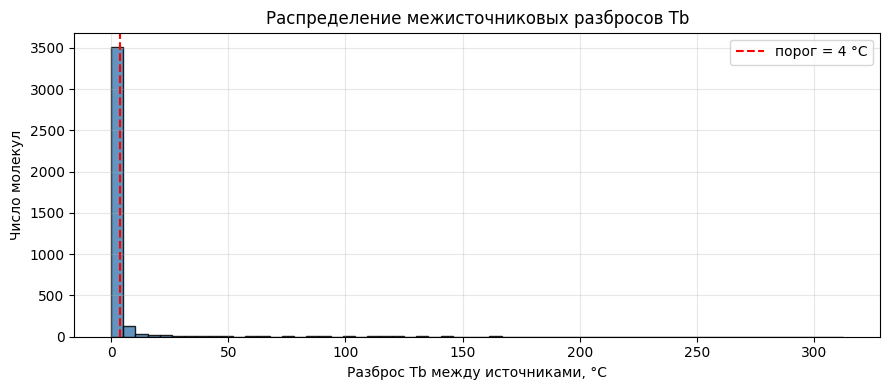

In [3]:
# Статистика пересечений и порог
n_per_mol = df.groupby("inchi")["source"].nunique()
print(f"Уникальных молекул:        {len(n_per_mol)}")
print(f"  из 1 источника:          {(n_per_mol == 1).sum()}")
print(f"  из 2 источников:         {(n_per_mol == 2).sum()}")
print(f"  из 3 источников:         {(n_per_mol == 3).sum()}")

# одно значение Tb на источник, затем разброс между источниками
src_mean = df.groupby(["inchi", "source"])["Tb"].mean()
spreads = []
for inchi, n in n_per_mol.items():
    if n >= 2:
        vals = src_mean.loc[inchi].values
        spreads.append(vals.max() - vals.min())
spreads = np.array(spreads)

THRESH = float(np.ceil(np.percentile(spreads, 90)))
print(f"\nПересекающихся молекул:    {len(spreads)}")
print(f"Разброс Tb между источниками: медиана {np.median(spreads):.1f}, "
      f"P90 {np.percentile(spreads, 90):.1f}, max {spreads.max():.1f} °C")
print(f"\nАвтоматический порог согласованности THRESH = {THRESH:.0f} °C")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(spreads, bins=60, color="steelblue", edgecolor="black", alpha=0.85)
ax.axvline(THRESH, color="red", linestyle="--", label=f"порог = {THRESH:.0f} °C")
ax.set_xlabel("Разброс Tb между источниками, °C")
ax.set_ylabel("Число молекул")
ax.set_title("Распределение межисточниковых разбросов Tb")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Шаг 3. Слияние: сначала объединяем источники, потом усредняем

Для каждой молекулы есть до трёх значений Tb (по одному на источник). Логика
(по рекомендации научрука — *«сначала объединяем источники, потом усредняем»*):

- **1 источник** → берём значение как есть;
- **несколько источников** → ищем самую большую согласованную группу (все значения
  внутри разброса ≤ `THRESH`):
  - вся группа согласована → усредняем все;
  - часть согласована (например 2 из 3) → усредняем согласованные, **один выброс
    отбрасываем**;
  - согласия нет → конфликт, берём значение приоритетного источника
    (chemeo > ochem > pubchem).

`n_sources` — число источников, реально вошедших в усреднённое значение; полезная
фича доверия для модели.

In [4]:
# Слияние
def best_cluster(values, T):
    # values: список (source, Tb). Возвращает максимальную согласованную подгруппу.
    order = sorted(range(len(values)), key=lambda i: values[i][1])
    best = []
    for i in range(len(order)):
        j = i
        while j + 1 < len(order) and \
              values[order[j + 1]][1] - values[order[i]][1] <= T:
            j += 1
        if j - i + 1 > len(best):
            best = order[i:j + 1]
    return [values[k] for k in best]

merged = []
n_single = n_avg = n_drop = n_conflict = 0
for inchi, g in df.groupby("inchi"):
    per_src = g.groupby("source")["Tb"].mean()
    vals = [(s, float(per_src[s])) for s in per_src.index]
    rep = g.iloc[0]

    if len(vals) == 1:
        tb, used, status = vals[0][1], [vals[0][0]], "single"
        n_single += 1
    else:
        cluster = best_cluster(vals, THRESH)
        if len(cluster) >= 2:
            tb = float(np.mean([v for _, v in cluster]))
            used = [s for s, _ in cluster]
            if len(cluster) == len(vals):
                status = "averaged"; n_avg += 1
            else:
                status = "averaged_drop_outlier"; n_drop += 1
        else:
            best = min(vals, key=lambda v: PRIORITY[v[0]])
            tb, used, status = best[1], [best[0]], "conflict"
            n_conflict += 1

    merged.append({
        "inchi": inchi, "smiles": rep["smiles"], "Tb": tb,
        "n_sources": len(used), "sources": "+".join(sorted(used)),
        "status": status, "name": rep["name"], "cas": rep["cas"],
    })

mdf = pd.DataFrame(merged)
print(f"Молекул после слияния:                 {len(mdf)}")
print(f"  один источник (single):              {n_single}")
print(f"  усреднены все источники (averaged):  {n_avg}")
print(f"  усреднены, один выброс отброшен:     {n_drop}")
print(f"  конфликт, взят приоритетный:         {n_conflict}")

Молекул после слияния:                 8873
  один источник (single):              5092
  усреднены все источники (averaged):  3413
  усреднены, один выброс отброшен:     109
  конфликт, взят приоритетный:         259


## Шаг 4. Проверки: дескрипторы и физический диапазон

Считаем дескрипторы RDKit (понадобятся для поиска выбросов и EDA) и проверяем,
что все Tb попадают в физически осмысленный диапазон [−200, 700] °C.

In [5]:
# Дескрипторы + физический фильтр
def descriptors(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    return {
        "mw":      Descriptors.MolWt(m),
        "n_heavy": m.GetNumHeavyAtoms(),
        "n_rings": rdMolDescriptors.CalcNumRings(m),
        "n_arom":  rdMolDescriptors.CalcNumAromaticRings(m),
        "logp":    Descriptors.MolLogP(m),
        "tpsa":    Descriptors.TPSA(m),
        "n_hbd":   rdMolDescriptors.CalcNumHBD(m),
        "n_hba":   rdMolDescriptors.CalcNumHBA(m),
        "n_rot":   rdMolDescriptors.CalcNumRotatableBonds(m),
    }

desc = mdf["smiles"].apply(descriptors)
bad_smiles = desc.isna().sum()
mdf = mdf[desc.notna()].reset_index(drop=True)
desc = desc.dropna().reset_index(drop=True)
mdf = pd.concat([mdf, pd.DataFrame(list(desc))], axis=1)

in_range = mdf["Tb"].between(TEMP_MIN, TEMP_MAX)
print(f"Не распарсился SMILES:            {bad_smiles}")
print(f"Вне диапазона [{TEMP_MIN:.0f}, {TEMP_MAX:.0f}] °C:  {(~in_range).sum()}")
mdf = mdf[in_range].reset_index(drop=True)
print(f"Молекул после проверок:           {len(mdf)}")

Не распарсился SMILES:            0
Вне диапазона [-200, 700] °C:  0
Молекул после проверок:           8873


## Шаг 5. Поиск выбросов (3σ по многофакторной модели)

Строим линейную модель `Tb ~ дескрипторы` и считаем остатки. Молекулы с остатком
больше 3σ — кандидаты в выбросы (опечатки в данных).

**Что защищаем от удаления:**

- молекулы из **2–3 источников** — значение подтверждено независимыми базами,
  это не ошибка данных;
- **очень лёгкие молекулы** (≤ 3 тяжёлых атома, например метан, этан, пропан) —
  их Tb табличная и общеизвестная, ошибкой быть не может; линейная модель просто
  структурно не описывает лёгкие газы и даёт по ним ложный 3σ-остаток.

Реально удаляются только неподтверждённые крупные молекулы с физически
неправдоподобной Tb (как правило перепутанные температура кипения и разложения).

In [6]:
# 3σ-выбросы
feat = ["mw", "n_heavy", "n_rings", "n_arom", "logp", "tpsa", "n_hbd", "n_hba", "n_rot"]
X = np.column_stack([np.ones(len(mdf)), mdf[feat].values])
y = mdf["Tb"].values
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
resid = y - X @ coef
sigma = float(resid.std())

is_out    = np.abs(resid) > 3 * sigma
# защищаем кросс-подтверждённые и очень лёгкие молекулы
protected = (mdf["n_sources"].values >= 2) | (mdf["n_heavy"].values <= 3)
drop      = is_out & ~protected

print(f"σ остатков модели:                       {sigma:.1f} °C")
print(f"Кандидатов в выбросы (|остаток| > 3σ):   {int(is_out.sum())}")
print(f"  защищены (кросс-подтв./лёгкие, СОХРАНЕНЫ): {int((is_out & protected).sum())}")
print(f"  удаляются:                                {int(drop.sum())}")

worst = mdf.loc[is_out].assign(residual=resid[is_out])
worst = worst.reindex(worst["residual"].abs().sort_values(ascending=False).index)
print("\nТоп-10 кандидатов в выбросы:")
print(worst[["name", "mw", "Tb", "n_sources", "residual"]].head(10).to_string(index=False))

mdf = mdf.loc[~drop].reset_index(drop=True)
print(f"\nМолекул после удаления выбросов: {len(mdf)}")

σ остатков модели:                       61.1 °C
Кандидатов в выбросы (|остаток| > 3σ):   47
  защищены (кросс-подтв./лёгкие, СОХРАНЕНЫ): 4
  удаляются:                                43

Топ-10 кандидатов в выбросы:
                                                                                                                                      name       mw         Tb  n_sources    residual
                                                                                                                                   Brij 78 1151.561 100.000000          1 -456.248689
                                                                                                                                   Brij 98 1149.545 100.000000          1 -445.351486
                                                                                                                                  Bath wax  891.501 260.000000          1 -381.997846
(7S,9S)-9-acetyl-7-[(2R,4S,5S,6S)-4-amino-5-hydroxy-6-m

## Шаг 6. EDA — дашборд

Шесть графиков: распределение Tb и связь Tb с ключевыми дескрипторами.

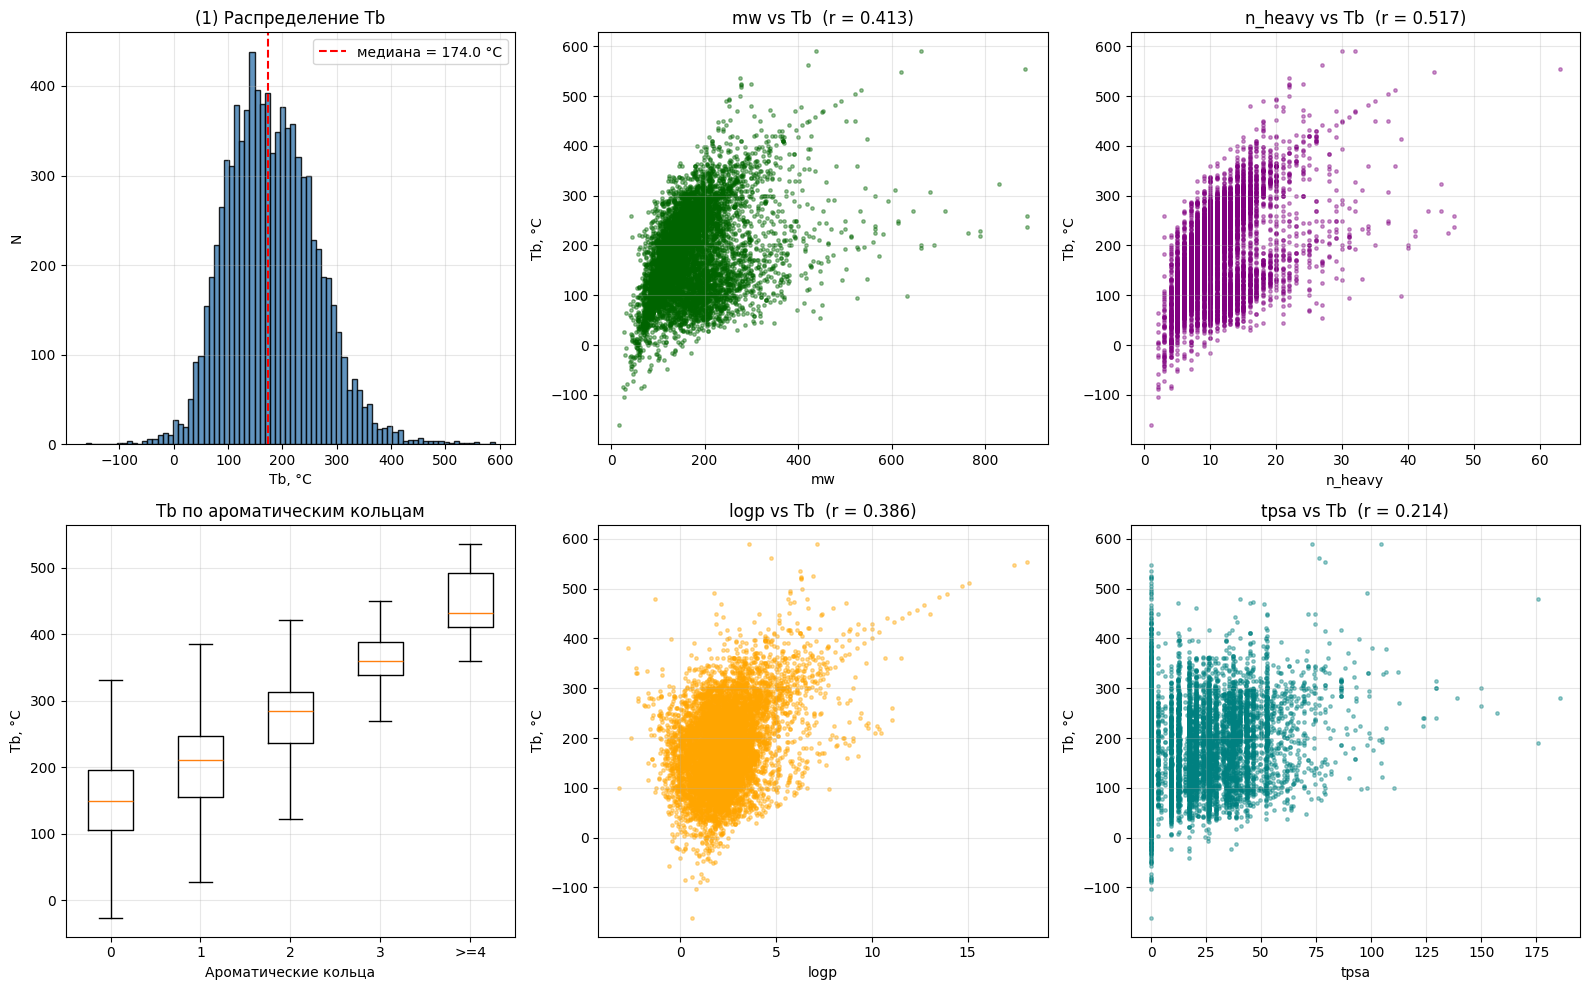

Сохранено: eda_dashboard_merged.png


In [12]:
# EDA-дашборд
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(mdf["Tb"], bins=80, color="steelblue", edgecolor="black", alpha=0.85)
ax.axvline(mdf["Tb"].median(), color="red", linestyle="--",
           label=f"медиана = {mdf['Tb'].median():.1f} °C")
ax.set_xlabel("Tb, °C"); ax.set_ylabel("N"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("(1) Распределение Tb")

for ax, col, color in [
    (axes[0, 1], "mw",      "darkgreen"),
    (axes[0, 2], "n_heavy", "purple"),
    (axes[1, 1], "logp",    "orange"),
    (axes[1, 2], "tpsa",    "teal"),
]:
    ax.scatter(mdf[col], mdf["Tb"], s=6, alpha=0.4, color=color)
    r = mdf[[col, "Tb"]].corr().iloc[0, 1]
    ax.set_xlabel(col); ax.set_ylabel("Tb, °C")
    ax.set_title(f"{col} vs Tb  (r = {r:.3f})"); ax.grid(alpha=0.3)

ax = axes[1, 0]
groups = [mdf.loc[mdf["n_arom"].clip(upper=4) == k, "Tb"].values for k in range(5)]
ax.boxplot(groups, tick_labels=["0", "1", "2", "3", ">=4"], showfliers=False)
ax.set_xlabel("Ароматические кольца"); ax.set_ylabel("Tb, °C")
ax.set_title("Tb по ароматическим кольцам"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_dashboard_merged.png", dpi=110, bbox_inches="tight")
plt.show()
print("Сохранено: eda_dashboard_merged.png")

## Шаг 7. Sanity-check на эталонных молекулах

Сверяем Tb известных веществ с литературой. Расхождение > 3 °C — повод насторожиться.

In [13]:
# Sanity-check
reference = [
    ("Methane",       "C",          -161.5),
    ("Ethane",        "CC",          -88.6),
    ("Methanol",      "CO",           64.7),
    ("Ethanol",       "CCO",          78.4),
    ("Benzene",       "c1ccccc1",     80.1),
    ("Toluene",       "Cc1ccccc1",   110.6),
    ("Acetone",       "CC(C)=O",      56.1),
    ("Diethyl ether", "CCOCC",        34.6),
    ("n-Hexane",      "CCCCCC",       68.7),
    ("n-Heptane",     "CCCCCCC",      98.4),
    ("n-Octane",      "CCCCCCCC",    125.7),
    ("Chloroform",    "ClC(Cl)Cl",    61.2),
    ("Acetic acid",   "CC(=O)O",     118.1),
]
ref_tb = dict(zip(mdf["inchi"], mdf["Tb"]))

print("{:16s} {:>10s} {:>10s} {:>9s}".format("Вещество", "Литер.", "Наше", "delta"))
print("-" * 50)
found = 0
for name, smi, lit in reference:
    inchi = MolToInchi(Chem.MolFromSmiles(smi), options="/SNon")
    if inchi in ref_tb:
        our = ref_tb[inchi]
        flag = "" if abs(our - lit) <= 3.0 else "  <-- расхождение"
        print("{:16s} {:>10.1f} {:>10.2f} {:>+9.2f}{}".format(
            name, lit, our, our - lit, flag))
        found += 1
    else:
        print("{:16s} {:>10.1f} {:>10s}".format(name, lit, "нет"))
print(f"\nНайдено {found} из {len(reference)} эталонных молекул")

Вещество             Литер.       Наше     delta
--------------------------------------------------
Methane              -161.5    -161.50     +0.00
Ethane                -88.6     -88.53     +0.07
Methanol               64.7      64.81     +0.11
Ethanol                78.4      78.32     -0.08
Benzene                80.1      79.83     -0.27
Toluene               110.6     110.55     -0.05
Acetone                56.1      56.01     -0.09
Diethyl ether          34.6      34.61     +0.01
n-Hexane               68.7      68.75     +0.05
n-Heptane              98.4      98.34     -0.06
n-Octane              125.7     125.69     -0.01
Chloroform             61.2      61.30     +0.10
Acetic acid           118.1     117.37     -0.73

Найдено 13 из 13 эталонных молекул


## Шаг 8. Распределение классов

Смотрим состав датасета: по числу источников, по статусу слияния и по элементам.

По числу источников (n_sources):
n_sources
1    5308
2    2644
3     878

По статусу слияния:
status
single                   5050
averaged                 3413
conflict                  258
averaged_drop_outlier     109

Топ-12 элементов:
  C      72915
  O       9661
  F       3779
  N       3307
  Cl      2399
  Si       718
  S        686
  Br       642
  P        143
  I        130
  Sn        33
  B         32


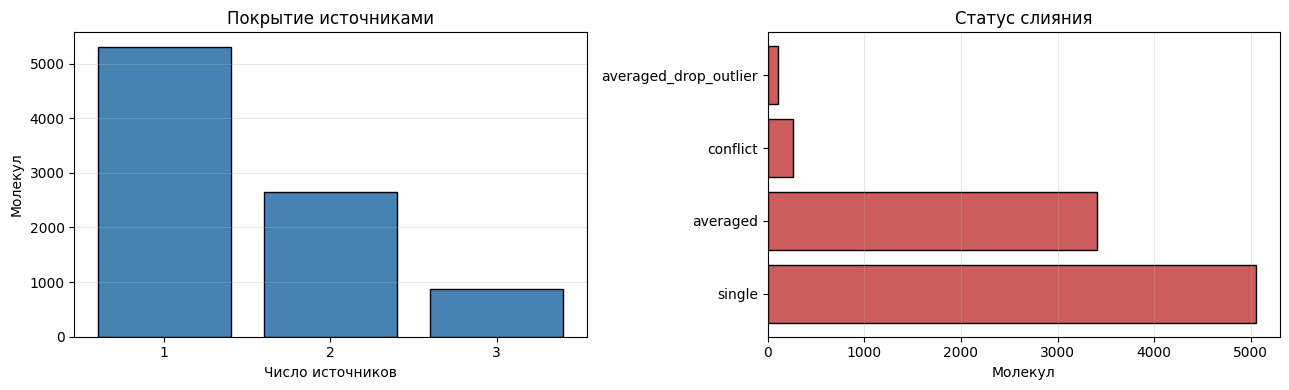

In [14]:
# Распределение классов
print("По числу источников (n_sources):")
print(mdf["n_sources"].value_counts().sort_index().to_string())
print("\nПо статусу слияния:")
print(mdf["status"].value_counts().to_string())

elem = Counter()
for smi in mdf["smiles"]:
    m = Chem.MolFromSmiles(smi)
    if m is None:
        continue
    for a in m.GetAtoms():
        elem[a.GetSymbol()] += 1
print("\nТоп-12 элементов:")
for e, n in elem.most_common(12):
    print(f"  {e:3s} {n:>8d}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vc = mdf["n_sources"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Число источников"); axes[0].set_ylabel("Молекул")
axes[0].set_title("Покрытие источниками"); axes[0].grid(alpha=0.3, axis="y")

sc = mdf["status"].value_counts()
axes[1].barh(sc.index, sc.values, color="indianred", edgecolor="black")
axes[1].set_xlabel("Молекул"); axes[1].set_title("Статус слияния")
axes[1].grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## Шаг 9. Запись итогового SDF

Сохраняем `merged_nbp.sdf` с **единым для всех молекул набором полей** независимо
от исходной базы:

- `Temperature_Celsius` — целевая величина (NBP);
- `Pressure_Atm` — давление (≈ 1 атм);
- `SMILES` — каноничный SMILES (RDKit);
- `InChI` — InChI без стерео, ключ группировки;
- `compound`, `CAS` — название и регистрационный номер;
- `source` — какие базы вошли в значение;
- `n_sources` — число источников в усреднении (фича доверия);
- `merge_status` — как получено значение (single / averaged / …);
- `measurement_type` — тип измерения.

In [10]:
# Запись SDF (путь с кириллицей -> пишем через файловый объект)
fout = open(OUT_SDF, "w")
writer = SDWriter(fout)
n_written = 0
for _, r in mdf.iterrows():
    m = Chem.MolFromSmiles(r["smiles"])
    if m is None:
        continue
    m.SetProp("Temperature_Celsius", f"{r['Tb']:.2f}")
    m.SetProp("Pressure_Atm",        "1.0")
    m.SetProp("SMILES",              r["smiles"])
    m.SetProp("InChI",               r["inchi"])
    m.SetProp("compound",            str(r["name"] or ""))
    m.SetProp("CAS",                 str(r["cas"] or ""))
    m.SetProp("source",              r["sources"])
    m.SetProp("n_sources",           str(int(r["n_sources"])))
    m.SetProp("merge_status",        r["status"])
    m.SetProp("measurement_type",    "normal_bp")
    writer.write(m)
    n_written += 1
writer.close()
fout.close()
print(f"Записано в {OUT_SDF}: {n_written} молекул")

Записано в C:\Users\User\Desktop\диплом тест\data_ml\merged_nbp.sdf: 8830 молекул


## Итог

`merged_nbp.sdf` — объединённый датасет NBP из трёх баз, готовый для ML.

Что сделано:

- три источника (chemeo, ochem, pubchem) приведены к единому формату и
  сгруппированы по InChI без стерео;
- порог согласованности подобран автоматически по распределению разбросов;
- согласованные источники усреднены, расходящиеся выбросы отброшены,
  неразрешимые конфликты разрешены по приоритету chemeo > ochem > pubchem;
- проверены физический диапазон и 3σ-выбросы (кросс-подтверждённые молекулы
  защищены от удаления);
- EDA, sanity-check на эталонах и распределение классов подтверждают качество.

Колонка `n_sources` сохранена как фича доверия для модели.

## Обозначения `merge_status`

Поле `merge_status` у каждой молекулы показывает, как получено значение Tb:

| Значение | Что означает |
|---|---|
| `single` | молекула есть только в одной базе — значение взято как есть |
| `averaged` | молекула в нескольких базах, все согласованы (разброс ≤ порога) — Tb усреднена по всем источникам |
| `averaged_drop_outlier` | молекула в нескольких базах, согласована часть — усреднены согласованные, выбивающийся источник отброшен |
| `conflict` | источники расходятся (разброс > порога) — взято значение приоритетного источника (chemeo > ochem > pubchem) |

`single`, `averaged`, `averaged_drop_outlier` — надёжные значения;
`conflict` — спорные молекулы, по которым базы не сошлись.

In [11]:
# Дополнительный SDF без конфликтных молекул
OUT_CLEAN = os.path.join(BASE, "data_ml", "merged_nbp_clean.sdf")
clean = mdf[mdf["status"] != "conflict"].reset_index(drop=True)

fout = open(OUT_CLEAN, "w")
writer = SDWriter(fout)
for _, r in clean.iterrows():
    m = Chem.MolFromSmiles(r["smiles"])
    if m is None:
        continue
    m.SetProp("Temperature_Celsius", f"{r['Tb']:.2f}")
    m.SetProp("Pressure_Atm",        "1.0")
    m.SetProp("SMILES",              r["smiles"])
    m.SetProp("InChI",               r["inchi"])
    m.SetProp("compound",            str(r["name"] or ""))
    m.SetProp("CAS",                 str(r["cas"] or ""))
    m.SetProp("source",              r["sources"])
    m.SetProp("n_sources",           str(int(r["n_sources"])))
    m.SetProp("merge_status",        r["status"])
    m.SetProp("measurement_type",    "normal_bp")
    writer.write(m)
writer.close()
fout.close()
print(f"Записано в {OUT_CLEAN}: {len(clean)} молекул (без conflict)")

Записано в C:\Users\User\Desktop\диплом тест\data_ml\merged_nbp_clean.sdf: 8572 молекул (без conflict)
